# Quantum GAN (QGAN) for mask generation

Moving from a standard U-Net to a Quantum GAN (QGAN) for mask generation puts you at the intersection of Quantum Machine Learning (QML) and Generative AI.Using a QGAN for segmentation masks is fundamentally different from a U-Net. In a U-Net, you are performing pixel-wise classification. In a QGAN approach, your Generator is learning to produce an entire 2D binary distribution (the mask) that the Discriminator cannot distinguish from the "ground truth" masks.

## 1. Feasibility
This is a new area for research and there are ways to implement this but with caveats. Real-world medical images (e.g., $512 \times 512$) are too large for current quantum hardware. Most successful research (like the QU-Net or PQWGAN) uses a Hybrid Approach:Classical Encoder: Compresses the medical image into a small latent vector.Quantum Generator: A Variational Quantum Circuit (VQC) that processes this vector and outputs a quantum state representing the mask features.Classical Decoder: Converts the quantum output back into the full-resolution mask.

## 2. How to learn/build this
If you want to build this, I recommend the Hybrid "Quantum Bottleneck" approach rather than a "Pure" QGAN.

Step-by-Step Learning Path:

* Master the Classical GAN: First, build a "Pix2Pix" GAN where the input is an MRI and the output is a mask. This will be your baseline.
* Learn PennyLane or Qiskit: Use PennyLane for its seamless integration with PyTorch/TensorFlow.
* The Quantum Layer: Replace the bottleneck of your U-Net (the middle part where the image is most compressed) with a Variational Quantum Circuit (VQC).
    * Encoding: Use Angle Encoding to map pixels to qubit rotations.
    * Processing: Use strongly entangling layers.
    * Measurement: Measure the expectation values to get classical data for the decoder.

## 3. Working on an Experiment
Why do this over U-Net? Research suggests that quantum circuits can capture certain global correlations in image data more efficiently than classical convolutions, potentially leading to better segmentation with fewer training parameters. This is the "Quantum Advantage" everyone is hunting for.Tip: Start by resizing your images to $28 \times 28$ or $64 \times 64$. Trying to run a $512 \times 512$ image through a simulator will likely crash your environment or take weeks to train!

In [ ]:
!pip install --quiet pennylane torch torchvision matplotlib numpy amazon-braket-pennylane-plugin

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 388.0/388.0 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.8/245.8 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.3/152.3 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14

## Beginning the Experiment
Let's ground this experiment with a practical, step-by-step implementation. We will build a Hybrid QGAN-Pix2Pix framework. Because we need to process images, we will design a Quantum Bottleneck (QU-Net style):
* Classical Encoder: Downsamples a $64 \times 64$ medical image into a small feature vector.
* Quantum Generator (VQC): A 4-qubit parameterized quantum circuit that processes these features, applies quantum entanglement, and measures the output.
* Classical Decoder: Upsamples the quantum output back into a $64 \times 64$ binary mask.

In [ ]:
import torch, numpy as np, matplotlib.pyplot as plt
import torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
import pennylane as qml

torch.manual_seed(42); np.random.seed(42)

In [ ]:
n_qubits = 4

# Training: PennyLane default.mixed — supports autograd + noise channels
dev_train = qml.device("default.mixed", wires=n_qubits)

# Readout: Braket DM — used only post-training (no gradients needed)
# Gives access to the full density matrix via qml.density_matrix()
dev_dm = qml.device("braket.local.qubit", backend="braket_dm",
                     wires=n_qubits, shots=None)

### Building our circuit
### 1. Training Circuit (circuit)
This circuit is the heart of your Quantum Generator and is designed to integrate directly with a PyTorch training pipeline.
* qml.AngleEmbedding (Encoding): This step performs the initial data injection. It maps classical features—received from the classical encoder—into quantum states by rotating qubits around the X-axis by an angle proportional to the input data.
* qml.StronglyEntanglingLayers (Processing): This is the core processing stage. It uses learnable weights to create complex correlations (entanglement) between qubits. This allows the model to capture global patterns in the image data that standard classical convolutions might miss.
* qml.DepolarizingChannel (Hardware Noise Simulation): By adding a 1% probability of a bit or phase flip on each qubit, you are performing Noise-Aware Circuit Learning (NACL). This trains the model to remain robust against errors it would encounter on actual quantum hardware.
* qml.expval(qml.PauliZ(i)) (Measurement): This step converts the processed quantum state back into classical expectation values ranging from -1 to 1. These values are then passed to the classical decoder to be upsampled into the final segmentation mask.

### 2. Density Matrix Circuit (circuit_dm)
This circuit is used for Hardware Feasibility Analysis and detailed diagnostics rather than direct training.
* qml.density_matrix: Unlike the training circuit that returns a simple list of values, this returns the full density matrix ($\rho$).
* Mixed State Representation: While a standard state vector describes a perfectly isolated system, the density matrix accounts for mixed states—the result of decoherence and the depolarizing noise you have introduced.
* Diagnostic Value: This allows you to evaluate how much "quantumness" is preserved during the process. If the noise is too high, the density matrix will decohere into a maximally mixed state, indicating the circuit may be too deep for current hardware.

### 3. PyTorch Integration (quantum_layer)
The qml.qnn.TorchLayer wrapper transforms your quantum circuit into a standard PyTorch module.
* Seamless Backpropagation: It allows PyTorch's Adam or SGD optimizers to update the quantum weights (configured here as 3 layers) just as they would for a classical neural network.
* Hybrid Data Flow: In your QU-Net approach, this layer acts as the "bottleneck," receiving a small latent vector from the encoder and passing processed quantum features to the decoder for mask reconstruction.

In [ ]:
@qml.qnode(dev_train, interface="torch")
def circuit(inputs, weights):
    qml.AngleEmbedding(inputs * np.pi, wires=range(n_qubits), rotation="X")
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    for i in range(n_qubits):
        qml.DepolarizingChannel(0.01, wires=i)
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

@qml.qnode(dev_dm)   # no torch interface — only used for numpy readout
def circuit_dm(inputs, weights):
    qml.AngleEmbedding(inputs * np.pi, wires=range(n_qubits), rotation="X")
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    for i in range(n_qubits):
        qml.DepolarizingChannel(0.01, wires=i)
    return qml.density_matrix(wires=range(n_qubits))

quantum_layer = qml.qnn.TorchLayer(circuit, {"weights": (3, n_qubits, 3)})

### Architectures designed for medical image segmentation
They follow a U-Net pattern, which is the "gold standard" for creating masks. The core difference is how they handle the information "bottleneck" where the image is most compressed.

### 1. The U-Net Framework (Shared Logic)
Both generators use Skip Connections (the torch.cat lines in the forward pass).
* Encoder (enc1 to enc3): These layers downsample the MRI, extracting high-level features (like the presence of a tumor) while losing spatial detail.
* Decoder (dec1 to dec3): These layers upsample the features back to the original image size.
* Skip Connections: By concatenating s2 with dec1 and s1 with dec2, you are "passing" the sharp edges and spatial details from the beginning of the network directly to the end. This is why U-Nets are so good at drawing clean boundaries.

### 2. HybridGenerator: The Quantum Experiment
This class places a Quantum Variational Circuit at the very center of the bottleneck.
* self.to_q: This shrinks the massive image data down to a size the quantum computer can handle (n_qubits). The Tanh() is critical because quantum gates (like $RX$) expect angles; Tanh scales the data to $[-1, 1]$.
* self.q (Quantum Layer): Instead of a standard matrix multiplication, the data enters a Hilbert space. It uses entanglement to find global correlations between features.
* The Logic: You are testing if a quantum system can represent the "latent features" of a tumor more efficiently or accurately than a classical layer.

### 3. ClassicalGenerator: The Control Group
This is the Baseline. It is identical to the Hybrid version, but it uses a standard nn.Linear layer (self.b) at the bottleneck.
* Purpose: To verify your QGAN, you must train both. If the HybridGenerator achieves a higher Dice Score or more stable training than the ClassicalGenerator, you have found evidence for Quantum Advantage in medical segmentation.
* Fairness: Notice that both have an identical number of parameters in the encoder and decoder. This ensures that any difference in performance comes strictly from the quantum layer versus the linear layer.

### 4. Key Differences in the forward Pass
|Feature|Hybrid Generator|Classical Generator|
|-------|----------------|-------------------|
|Bottleneck|self.q (Variational Quantum Circuit)|self.b (Linear Layer)|
|Data Flow|Classical $\rightarrow$ Quantum $\rightarrow$ Classical|100% Classical Tensor math|
|Non-linearity|Controlled by Quantum Gate rotations|Controlled by torch.tanh|


In [ ]:
class HybridGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = nn.Sequential(nn.Conv2d(1, 16, 4, 2, 1), nn.ReLU())
        self.enc2 = nn.Sequential(nn.Conv2d(16, 32, 4, 2, 1), nn.ReLU())
        self.enc3 = nn.Sequential(nn.Conv2d(32, 64, 4, 4, 0), nn.ReLU())
        self.to_q   = nn.Sequential(nn.Linear(64*4*4, n_qubits), nn.Tanh())
        self.q      = quantum_layer
        self.from_q = nn.Sequential(nn.Linear(n_qubits, 64*4*4), nn.ReLU())
        self.dec1 = nn.Sequential(nn.ConvTranspose2d(64, 32, 4, 4, 0), nn.ReLU())
        self.dec2 = nn.Sequential(nn.ConvTranspose2d(64, 16, 4, 2, 1), nn.ReLU())
        self.dec3 = nn.Sequential(nn.ConvTranspose2d(32,  1, 4, 2, 1), nn.Sigmoid())

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(s1)
        s3 = self.enc3(s2)
        z  = self.from_q(self.q(self.to_q(s3.flatten(1)))).view(-1, 64, 4, 4)
        d1 = torch.cat([self.dec1(z),  s2], dim=1)
        d2 = torch.cat([self.dec2(d1), s1], dim=1)
        return self.dec3(d2)


class ClassicalGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = nn.Sequential(nn.Conv2d(1, 16, 4, 2, 1), nn.ReLU())
        self.enc2 = nn.Sequential(nn.Conv2d(16, 32, 4, 2, 1), nn.ReLU())
        self.enc3 = nn.Sequential(nn.Conv2d(32, 64, 4, 4, 0), nn.ReLU())
        self.to_b   = nn.Sequential(nn.Linear(64*4*4, n_qubits), nn.Tanh())
        self.b      = nn.Linear(n_qubits, n_qubits)
        self.from_b = nn.Sequential(nn.Linear(n_qubits, 64*4*4), nn.ReLU())
        self.dec1 = nn.Sequential(nn.ConvTranspose2d(64, 32, 4, 4, 0), nn.ReLU())
        self.dec2 = nn.Sequential(nn.ConvTranspose2d(64, 16, 4, 2, 1), nn.ReLU())
        self.dec3 = nn.Sequential(nn.ConvTranspose2d(32,  1, 4, 2, 1), nn.Sigmoid())

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(s1)
        s3 = self.enc3(s2)
        z  = self.from_b(torch.tanh(self.b(self.to_b(s3.flatten(1))))).view(-1, 64, 4, 4)
        d1 = torch.cat([self.dec1(z),  s2], dim=1)
        d2 = torch.cat([self.dec2(d1), s1], dim=1)
        return self.dec3(d2)

### Discriminator
In a GAN (Generative Adversarial Network), while the Generator is trying to create a realistic mask, this Discriminator is trying to catch it in a lie.Here is a breakdown of what makes this specific Discriminator architecture work for medical image segmentation:

### 1. The "2-Channel" Input Strategy
Notice the first layer: nn.Conv2d(2, 32, 4, 2, 1).
* Channel 1: The original MRI scan (the context).
* Channel 2: The predicted mask (the candidate).By using torch.cat([img, mask], dim=1), you are forcing the Discriminator to look at the mask in relation to the image. It isn't just asking "Does this look like a mask?"; it's asking "Does this mask actually fit the tumor shown in this MRI?"

### 2. Downsampling for Global Context
The Discriminator uses three convolutional steps with a stride of 2. This progressively reduces the spatial resolution ($64 \to 32 \to 16 \to 8$) while increasing the "depth" or feature complexity ($2 \to 32 \to 64 \to 128$).
* Lower layers look for local pixel inconsistencies (edges that are too sharp or too blurry).
* Higher layers look for global structural logic (e.g., "A tumor mask shouldn't be in the middle of a healthy lung").

### 3. Training Stability Features
* LeakyReLU(0.2): Standard for GANs. Unlike a normal ReLU, it allows a small gradient to pass through even when the neuron is inactive. This prevents the "dying ReLU" problem during the intense competition between the Generator and Discriminator.
* BatchNorm2d: Normalizes the activations. This is vital because the Generator's output (the "Fake" mask) changes constantly. Batch normalization keeps the Discriminator's learning stable despite the moving target.

### 4. The double() and Sigmoid()
* torch.cat(...).double(): This aligns with your earlier data type issues. It ensures the Discriminator is calculating with 64-bit precision, which matches the output of your density matrix simulations.
* nn.Sigmoid(): The final output is a single scalar between 0 (Fake) and 1 (Real).

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(2, 32, 4, 2, 1), nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.Flatten(), nn.Linear(128*8*8, 1), nn.Sigmoid()
        )
    def forward(self, img, mask):
        return self.model(torch.cat([img, mask], dim=1).double())

### Generating Dataset
We are building a controlled sandbox to simulate medical imaging data (like an MRI or CT scan) without needing an actual hospital dataset. This code programmatically generates synthetic tumors and their ground truth masks.

Here is the breakdown of the "math" behind your medical simulation:

### 1. Generating Elliptical "Tumors"
Unlike previous versions that used simple circles, this code uses coordinate rotation and scaling to create randomized ellipses.

* Rotation Matrix Math: The lines involving np.cos(a) and np.sin(a) apply a 2D rotation. This means your "cancers" aren't just circles; they are tilted at random angles a.
* Scaling (rx, ry): By dividing dx and dy by different radii, you create elongated shapes.
* The Result: This is much more realistic. Real tumors are rarely perfect circles; they are irregular, asymmetric blobs.

### 2. The Imaging Physics (Gaussian Gradients)
Instead of drawing a solid white block for the image, you use:
img += ... * np.exp(-(dist2)/2)

* This creates a Gaussian fall-off. The "tumor" is brightest at the center and gradually fades into the background.
* This simulates how radiation or magnetic resonance actually interacts with tissue—there is rarely a sharp, pixel-perfect edge in raw medical scans.

### 3. Binary Ground Truth (The "Answer Key")
While the Image is a fuzzy, fading gradient, the Mask is strictly binary:
mask[dist <= 1.0] = 1.0

* This defines a "hard" boundary. During training, you are telling the Quantum GAN: "Even though the edges of the tumor look fuzzy and gray in the MRI, I want you to draw a solid white line exactly where the radius is 1."

### 4. Adding "Scanner Noise"
The final img line adds two types of interference:

* 0.05 * np.random.randn: Gaussian Noise (simulating electronic static from the scanner).
* 0.1 * np.random.rand: Salt-and-Pepper / Bias noise (adding general graininess).
* np.clip(..., 0, 1): This ensures that after adding noise, no pixel is "brighter than white" or "darker than black."

### 5. Multi-Tumor Complexity
The for _ in range(np.random.randint(1, 4)) loop is a major step up.

* It places 1 to 3 tumors in the same image.
* They can overlap, merge, or be scattered.
* This forces your Quantum Bottleneck to encode much more complex spatial information than a single centered blob. It has to handle "multi-modal" distributions (multiple points of interest).

In [ ]:
class SyntheticMedicalDataset(Dataset):
    def __init__(self, num_samples=200, size=64):
        self.n, self.size = num_samples, size

    def __len__(self): return self.n

    def __getitem__(self, idx):
        S = self.size
        img, mask = np.zeros((S,S), np.float32), np.zeros((S,S), np.float32)
        y, x = np.ogrid[:S, :S]
        for _ in range(np.random.randint(1, 4)):
            cx, cy = np.random.randint(15, 49, 2)
            rx, ry = np.random.randint(5, 14), np.random.randint(5, 14)
            a = np.random.uniform(0, np.pi)
            dx = (x-cx)*np.cos(a) + (y-cy)*np.sin(a)
            dy = -(x-cx)*np.sin(a) + (y-cy)*np.cos(a)
            dist = np.sqrt((dx/rx)**2 + (dy/ry)**2)
            img  += np.random.uniform(0.6, 1.0) * np.exp(-(dist**2)/2)
            mask[dist <= 1.0] = 1.0
        img = np.clip(img + 0.05*np.random.randn(S,S) + 0.1*np.random.rand(S,S), 0, 1)
        return torch.tensor(img, dtype=torch.float64).unsqueeze(0), torch.tensor(mask, dtype=torch.float64).unsqueeze(0)

### The validation and telemetry suite
The Generator and Discriminator do the "work," these functions are the "dashboard" that tells you if the Quantum circuit is actually outperforming the Classical one.
### 1. dice (The Medical Standard)
The Dice Coefficient measures the overlap between your predicted mask and the ground truth.
* The Logic: It calculates $2 \times \text{intersection}$ divided by the total number of pixels in both masks.
* Thresholding (p = (pred > t).float()): Since your generator outputs probabilities (via Sigmoid), this converts them into a hard "Yes/No" binary mask.
* The Goal: You want this value to approach 1.0. In medical imaging, a Dice score above 0.7–0.8 is usually considered a strong result.

### 2. iou (The Intersection over Union)
Also known as the Jaccard Index, this is similar to Dice but more "punishing."
* The Logic: It calculates the area of overlap divided by the total area covered by both masks.
* Why? Dice is great for measuring how well you caught the tumor; IoU is great for measuring how much "extra" background you accidentally included. If Dice is high but IoU is low, your mask is likely too large (over-segmenting).

### 3. show (The Visual Comparison)
This is your Qualitative Analysis tool. It creates a 4-panel comparison for every epoch:
* Input: The raw synthetic MRI.
* GT (Ground Truth): The perfect "doctor-approved" mask.
* Quantum: The output from your HybridGenerator.
* Classical: The output from your ClassicalGenerator.
* The Benefit: This is where you can catch Mode Collapse. If the "Quantum" and "Classical" panels look identical regardless of the "Input," you know the generators aren't actually looking at the images.

### 4. plot (The "Quantum Advantage" Proof)
This generates your Learning Curves. It takes your training history (h) and plots the performance of both models side-by-side.
* Axes[0] (Dice Score): Watch for the "Quantum" line to cross the "Classical" line. If it does, you have empirical evidence that the quantum circuit provides a more efficient bottleneck for this task.
* Axes[1] (IoU Score): This verifies that the advantage isn't a fluke and holds up across different metrics.

In [ ]:
def dice(pred, tgt, t=0.5, eps=1e-6):
    p = (pred > t).float()
    return ((2*(p*tgt).sum((1,2,3))+eps) / (p.sum((1,2,3))+tgt.sum((1,2,3))+eps)).mean().item()

def iou(pred, tgt, t=0.5, eps=1e-6):
    p = (pred > t).float()
    return (((p*tgt).sum((1,2,3))+eps) / ((p+tgt).clamp(0,1).sum((1,2,3))+eps)).mean().item()

def show(img, real, fq, fc, epoch):
    fig, axes = plt.subplots(1, 4, figsize=(16,4))
    for ax, arr, title in zip(axes, [img,real,fq,fc], ["Input","GT","Quantum","Classical"]):
        ax.imshow(arr[0].squeeze().cpu().detach(), cmap="gray"); ax.set_title(title); ax.axis("off")
    plt.suptitle(f"Epoch {epoch}"); plt.tight_layout(); plt.show()

def plot(h):
    fig, axes = plt.subplots(1, 2, figsize=(14,4))
    for name in ["quantum","classical"]:
        axes[0].plot(h[f"{name}_dice"], label=name)
        axes[1].plot(h[f"{name}_iou"],  label=name)
    for ax, t in zip(axes, ["Dice","IoU"]):
        ax.set_xlabel("Epoch"); ax.set_title(t+" Score"); ax.legend(); ax.grid(True)
    plt.tight_layout(); plt.show()

In [ ]:
def train(n_epochs=20, batch_size=4, vis_every=5):
    dl  = DataLoader(SyntheticMedicalDataset(), batch_size=batch_size, shuffle=True)
    Gq  = HybridGenerator().double()
    Gc  = ClassicalGenerator().double()
    D   = Discriminator().double()
    oGq = optim.Adam(Gq.parameters(), lr=2e-4, betas=(0.5,0.999))
    oGc = optim.Adam(Gc.parameters(), lr=2e-4, betas=(0.5,0.999))
    oD  = optim.Adam(D.parameters(),  lr=2e-4, betas=(0.5,0.999))
    scheds = [optim.lr_scheduler.CosineAnnealingLR(o, n_epochs) for o in [oGq,oGc,oD]]
    bce, l1 = nn.BCELoss(), nn.L1Loss()
    h = defaultdict(list)

    for epoch in range(n_epochs):
        m = defaultdict(list)
        for imgs, masks in dl:
            B  = imgs.size(0)
            rl = torch.full((B,1), 0.9, dtype=torch.float64)
            fl = torch.full((B,1), 0.1, dtype=torch.float64)

            fq_d, fc_d = Gq(imgs).detach(), Gc(imgs).detach()
            oD.zero_grad()
            ((bce(D(imgs,masks),rl) + bce(D(imgs,fq_d),fl) + bce(D(imgs,fc_d),fl))/3).backward()
            oD.step()

            for opt, G, key in [(oGq,Gq,"quantum"),(oGc,Gc,"classical")]:
                opt.zero_grad()
                fake = G(imgs)
                (bce(D(imgs,fake),rl) + 100*l1(fake,masks) + 10*bce(fake,masks)).backward()
                opt.step()
                with torch.no_grad():
                    m[f"{key}_dice"].append(dice(fake, masks))
                    m[f"{key}_iou"].append(iou(fake, masks))

        for k,v in m.items(): h[k].append(np.mean(v))
        for s in scheds: s.step()
        print(f"Epoch {epoch+1:>3}/{n_epochs} | "
              f"Q Dice {h['quantum_dice'][-1]:.4f} IoU {h['quantum_iou'][-1]:.4f} | "
              f"C Dice {h['classical_dice'][-1]:.4f} IoU {h['classical_iou'][-1]:.4f}")
        if (epoch+1) % vis_every == 0:
            with torch.no_grad(): show(imgs, masks, Gq(imgs), Gc(imgs), epoch+1)

    plot(h)
    return Gq, Gc, h

Epoch   1/20 | Q Dice 0.1491 IoU 0.0851 | C Dice 0.1149 IoU 0.0625
Epoch   2/20 | Q Dice 0.2395 IoU 0.1471 | C Dice 0.0008 IoU 0.0004
Epoch   3/20 | Q Dice 0.6541 IoU 0.5175 | C Dice 0.5090 IoU 0.3897
Epoch   4/20 | Q Dice 0.7408 IoU 0.6139 | C Dice 0.7321 IoU 0.6047
Epoch   5/20 | Q Dice 0.7554 IoU 0.6311 | C Dice 0.7549 IoU 0.6313


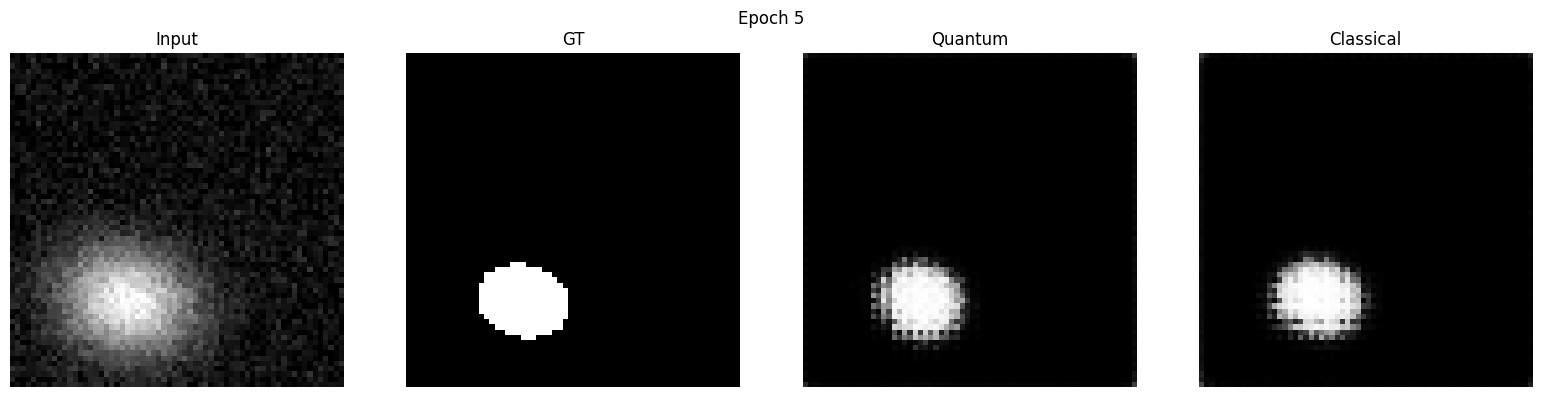

Epoch   6/20 | Q Dice 0.7642 IoU 0.6384 | C Dice 0.7511 IoU 0.6247
Epoch   7/20 | Q Dice 0.7940 IoU 0.6701 | C Dice 0.7715 IoU 0.6455
Epoch   8/20 | Q Dice 0.8030 IoU 0.6807 | C Dice 0.7731 IoU 0.6484
Epoch   9/20 | Q Dice 0.8043 IoU 0.6840 | C Dice 0.7589 IoU 0.6351
Epoch  10/20 | Q Dice 0.8103 IoU 0.6903 | C Dice 0.7639 IoU 0.6383


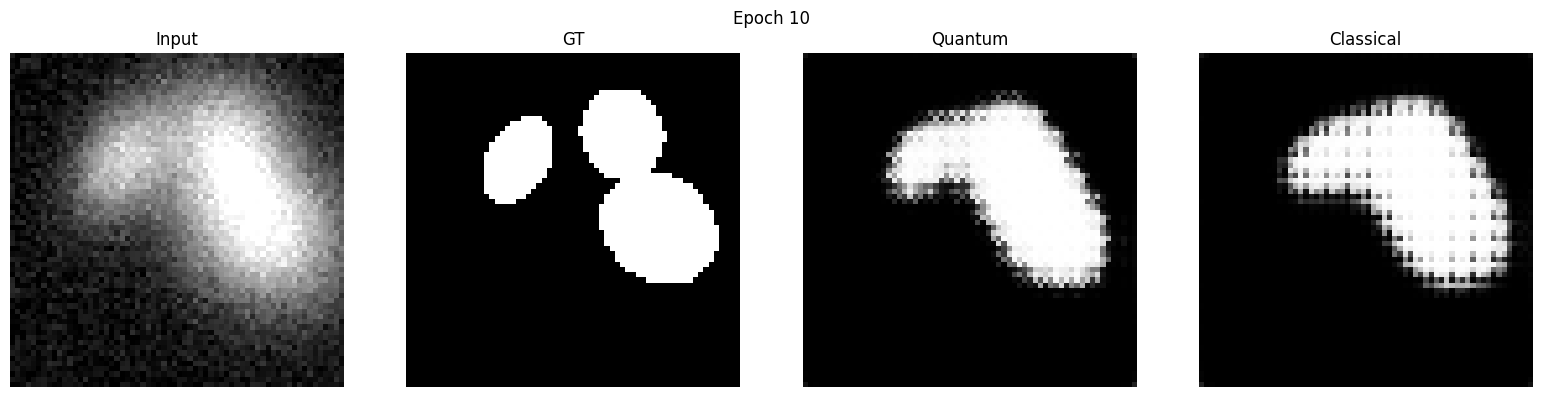

Epoch  11/20 | Q Dice 0.8125 IoU 0.6931 | C Dice 0.7643 IoU 0.6363
Epoch  12/20 | Q Dice 0.8081 IoU 0.6909 | C Dice 0.7504 IoU 0.6251
Epoch  13/20 | Q Dice 0.8131 IoU 0.6958 | C Dice 0.7681 IoU 0.6431
Epoch  14/20 | Q Dice 0.8154 IoU 0.6994 | C Dice 0.7463 IoU 0.6203
Epoch  15/20 | Q Dice 0.8342 IoU 0.7225 | C Dice 0.7747 IoU 0.6457


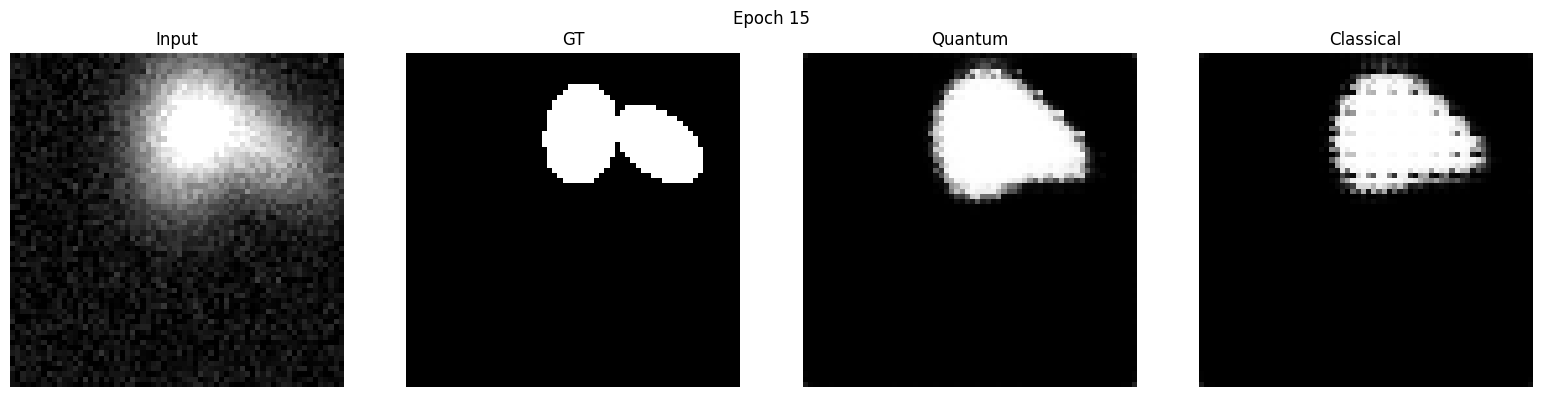

Epoch  16/20 | Q Dice 0.8413 IoU 0.7339 | C Dice 0.7934 IoU 0.6752
Epoch  17/20 | Q Dice 0.8192 IoU 0.7040 | C Dice 0.7528 IoU 0.6252
Epoch  18/20 | Q Dice 0.8237 IoU 0.7095 | C Dice 0.7561 IoU 0.6310
Epoch  19/20 | Q Dice 0.8199 IoU 0.7080 | C Dice 0.7480 IoU 0.6239
Epoch  20/20 | Q Dice 0.8266 IoU 0.7156 | C Dice 0.7622 IoU 0.6402


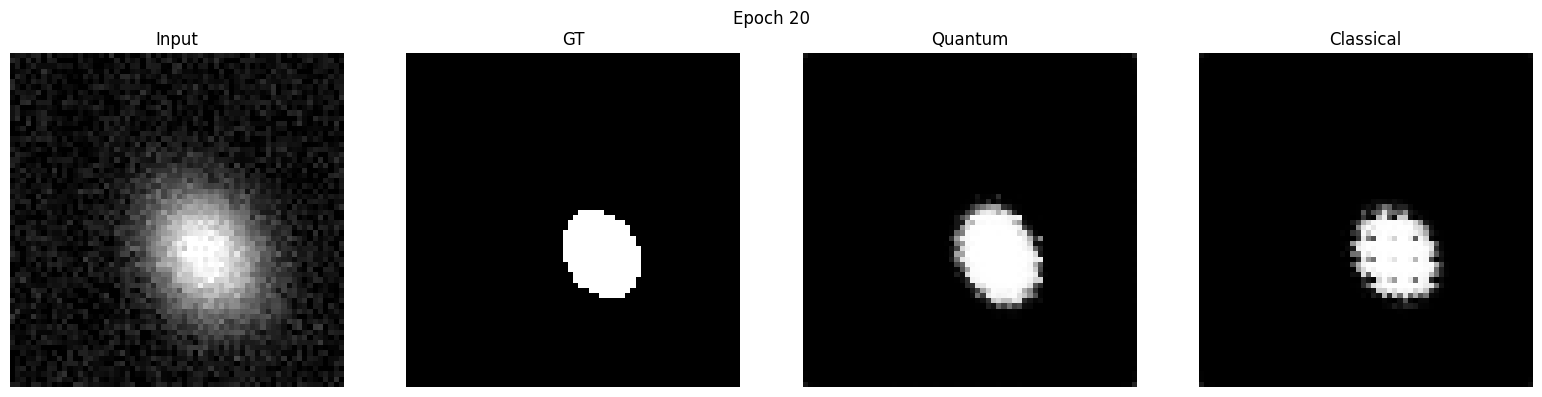

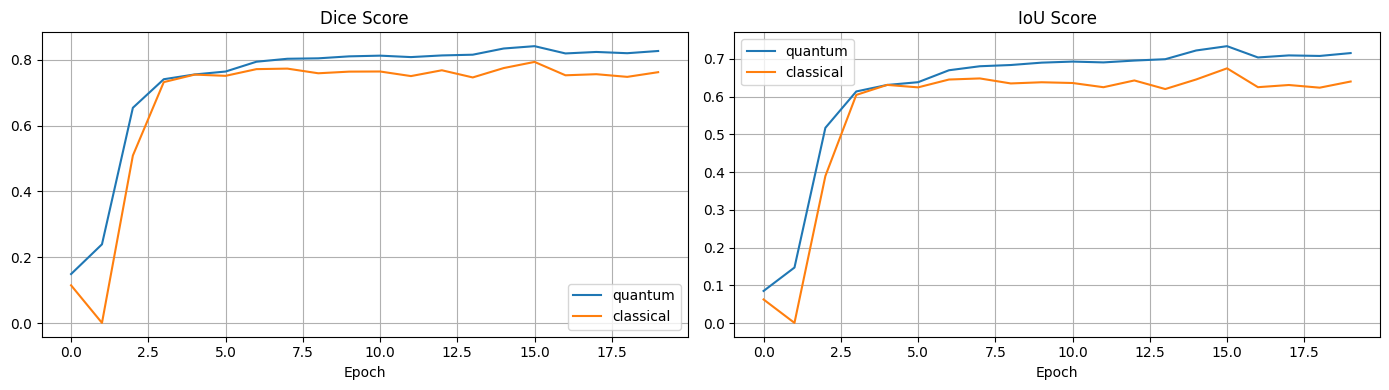

In [ ]:
Gq, Gc, history = train(n_epochs=20, batch_size=4, vis_every=5)

## Density Matrix Analysis

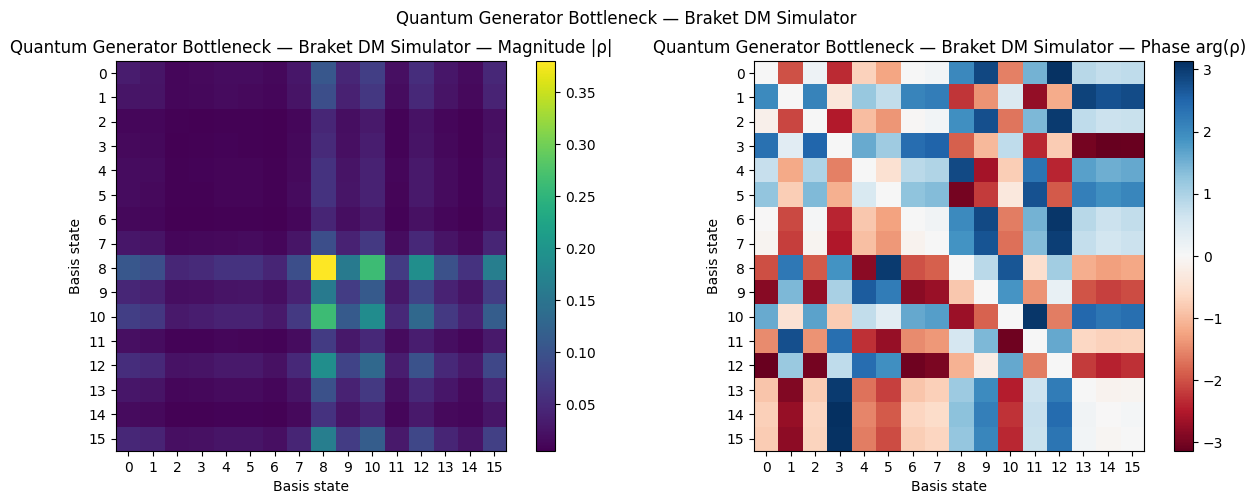

Tr(ρ)       = 1.000000  (should be 1.0)
Purity      = 0.9320  (pure=1.0, max-mixed=0.0625)
Von Neumann entropy = 0.3245 bits  (max=4 bits)
Eigenvalues: [9.653e-01 7.200e-03 6.100e-03 4.900e-03 4.800e-03 4.600e-03 2.100e-03
 1.500e-03 1.300e-03 1.200e-03 5.000e-04 3.000e-04 2.000e-04 1.000e-04
 0.000e+00 0.000e+00]


In [ ]:
def get_dm(generator, img):
    generator.eval()
    with torch.no_grad():
        s3      = generator.enc3(generator.enc2(generator.enc1(img)))
        latent  = generator.to_q(s3.flatten(1))          # [1, n_qubits]
        weights = generator.q.weights                     # trained params
        # Pass as numpy — circuit_dm has no torch interface (Braket readout only)
        lat_np  = latent[0].numpy()
        w_np    = weights.numpy()
        dm = circuit_dm(lat_np, w_np)                    # [2^n, 2^n] complex128
    return np.array(dm)


def plot_dm(dm, title="Density Matrix"):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    im0 = axes[0].imshow(np.abs(dm),   cmap="viridis")
    im1 = axes[1].imshow(np.angle(dm), cmap="RdBu", vmin=-np.pi, vmax=np.pi)
    axes[0].set_title(f"{title} — Magnitude |ρ|")
    axes[1].set_title(f"{title} — Phase arg(ρ)")
    plt.colorbar(im0, ax=axes[0]); plt.colorbar(im1, ax=axes[1])
    n = dm.shape[0]
    for ax in axes:
        ax.set_xticks(range(n)); ax.set_yticks(range(n))
        ax.set_xlabel("Basis state"); ax.set_ylabel("Basis state")
    plt.suptitle(title); plt.tight_layout(); plt.show()

    eigvals = np.linalg.eigvalsh(dm)
    purity  = np.real(np.trace(dm @ dm))
    ent_eig = eigvals[eigvals > 1e-12]
    entropy = -np.sum(ent_eig * np.log2(ent_eig))
    print(f"Tr(ρ)       = {np.trace(dm).real:.6f}  (should be 1.0)")
    print(f"Purity      = {purity:.4f}  (pure=1.0, max-mixed={1/2**n_qubits:.4f})")
    print(f"Von Neumann entropy = {entropy:.4f} bits  (max={n_qubits} bits)")
    print(f"Eigenvalues: {np.sort(eigvals.real)[::-1].round(4)}")


sample_img, _ = SyntheticMedicalDataset(num_samples=1)[0]
sample_img = sample_img.unsqueeze(0)

dm = get_dm(Gq, sample_img)
plot_dm(dm, title="Quantum Generator Bottleneck — Braket DM Simulator")

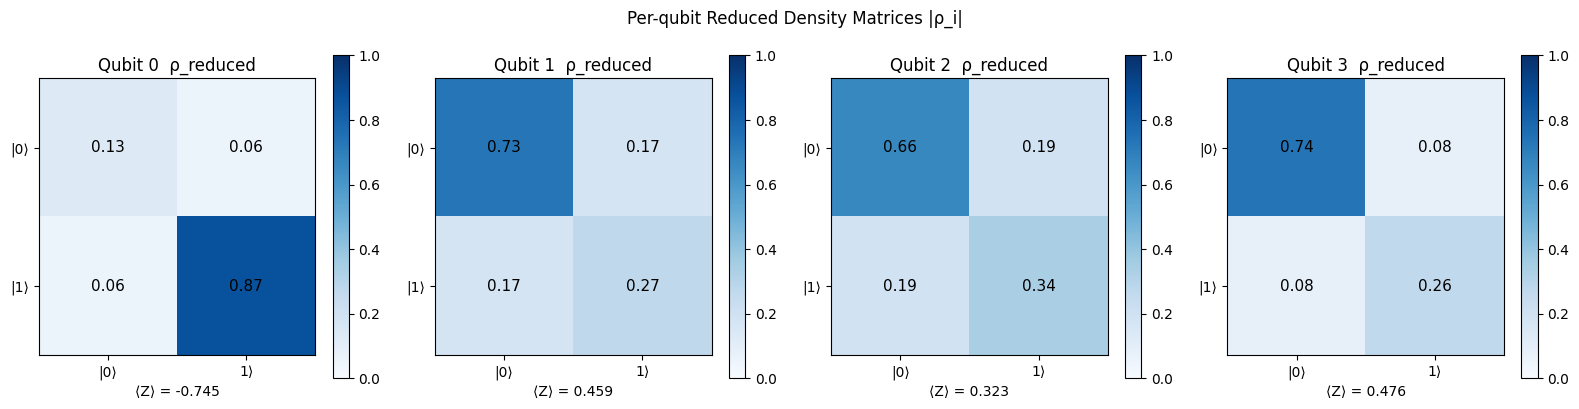

In [ ]:
def reduced_dm(dm, qubit, n=n_qubits):
    """Trace out all qubits except `qubit` to get a 2x2 reduced density matrix."""
    rho = dm.reshape([2]*n + [2]*n)
    keep = qubit
    trace_out = [i for i in range(n) if i != keep]
    # Trace over all other qubits by contracting diagonal indices
    for ax in sorted(trace_out, reverse=True):
        rho = np.trace(rho, axis1=ax, axis2=ax+n)
        n -= 1
    return rho.reshape(2, 2)


fig, axes = plt.subplots(1, n_qubits, figsize=(4*n_qubits, 4))
for i, ax in enumerate(axes):
    rdm = reduced_dm(dm, qubit=i, n=n_qubits)
    im  = ax.imshow(np.abs(rdm), cmap="Blues", vmin=0, vmax=1)
    ax.set_title(f"Qubit {i}  ρ_reduced")
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["|0⟩","1⟩"]); ax.set_yticklabels(["|0⟩","|1⟩"])
    for r in range(2):
        for c in range(2):
            ax.text(c, r, f"{np.abs(rdm[r,c]):.2f}", ha="center", va="center", fontsize=11)
    bloch_z = np.real(rdm[0,0] - rdm[1,1])
    ax.set_xlabel(f"⟨Z⟩ = {bloch_z:.3f}")
    plt.colorbar(im, ax=ax)
plt.suptitle("Per-qubit Reduced Density Matrices |ρ_i|")
plt.tight_layout(); plt.show()